# Data preprocessing

This notebook contains the code for preprocessing the data for the Random Forest analysis of factors influencing post-fire vegetation recovery in tropical peat forests in Indonesia. 

The notebook contains the following steps:
1. [Obtain Indonesia shapefile](#Indonesia-shapefile)
2. [Use MODIS fire alerts to identify study period](#MODIS-fire-alerts)
3. [Load burned area](#Burned-area)
4. [Set up pre-fire mean EVI and post-fire EVI timeseries](#EVI)

At the end, a NetCDF file containing all layers is exported for visualization. 

In [1]:
# General settings and important variables
projection = 'EPSG:3857' # reproject to Web Mercator (in m)


# Indonesia shapefile

In [2]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.pyplot as plt

# import country borders using natural earth data
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
world = gpd.read_file(shpfilename)

# select only Indonesia
indonesia = world[world['NAME'] == 'Indonesia']

# reproject
indonesia_reproj = indonesia.copy().to_crs('EPSG:3857')

[]

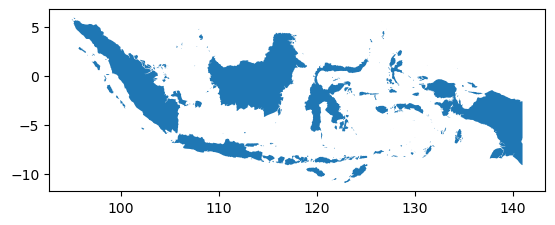

In [3]:
indonesia.plot()
plt.plot()

In [4]:
# get bounding box coordinates
indonesia.bounds

,minx,miny,maxx,maxy
0,95.012706,-10.922621,140.977627,5.910102


# MODIS fire alerts 
from NASA FIRMS

Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

$\rightarrow$ used to identify study period (which fire season) and as influencing factor (fire history)

In [5]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# read as geopandas dataframe
modis_fa_path = "input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"
modis_fa = gpd.read_file(modis_fa_path)

In [7]:
# filter to only keep TYPE 0 (presumed vegetation fire, not volcano activity etc.)
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0].copy()

In [8]:
# add column with year and month (as integers)
modis_fa_vf.loc[:,"YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

modis_fa_vf.loc[:,"MONTH"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=2).str[1].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

In [9]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,YEAR,MONTH
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),2001,1
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),2001,1
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),2001,1
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),2001,1
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),2001,1


Number of fire pixels in 2015: 2810394


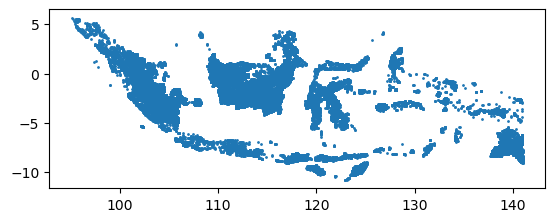

In [10]:
# plot fires in 2015
modis_fa_vf_2015 = modis_fa_vf[modis_fa_vf["YEAR"] == 2015]

print("Number of fire pixels in 2015:", end=' ')
print(modis_fa_vf_2015.size)

modis_fa_vf_2015.plot(markersize=1)
plt.show()

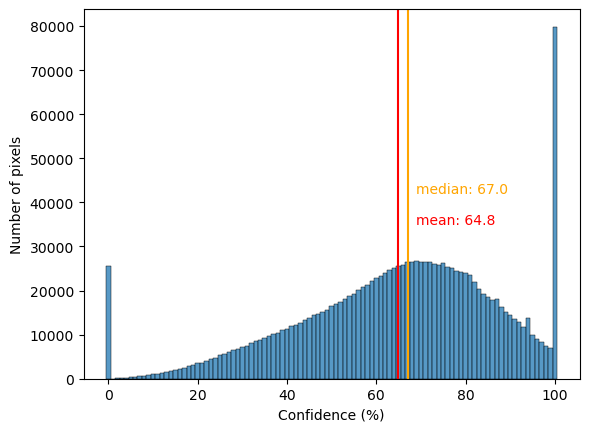

In [11]:
# check distribution of confidence
sns.histplot(x="CONFIDENCE", data=modis_fa_vf, discrete=True)
plt.ylabel("Number of pixels")
plt.xlabel("Confidence (%)")

# add mean confidence
mean_conf = modis_fa_vf.CONFIDENCE.mean()
plt.axvline(mean_conf, color="red")
plt.text(x=mean_conf+4, y=35000, s=f"mean: {round(mean_conf,1)}", color="red")

# add median confidence
med_conf = np.median(modis_fa_vf.CONFIDENCE)
plt.axvline(med_conf, color="orange")
plt.text(x=mean_conf+4, y=42000, s=f"median: {round(med_conf,1)}", color="orange")

plt.show()

In [12]:
np.std(modis_fa_vf.CONFIDENCE)

22.252626195361497

In [13]:
# add boolean column with confidence classification based on defined threshold
confidence_threshold = 85
modis_fa_vf['HIGH_CONFIDENCE'] = np.where(modis_fa_vf['CONFIDENCE'] >= confidence_threshold, True, False)

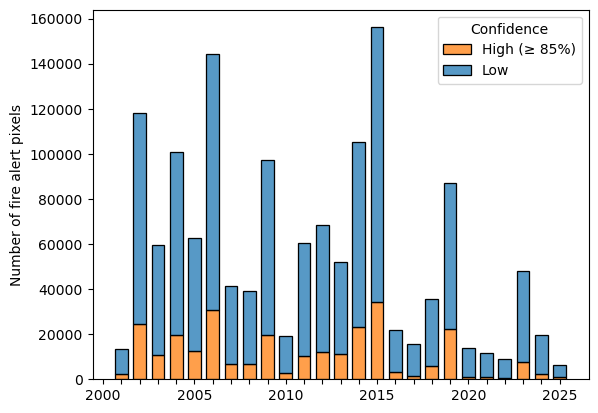

In [14]:
# check nr of fires per year
sns.histplot(x="YEAR", 
             hue="HIGH_CONFIDENCE", multiple="stack", 
             legend=False,
             data=modis_fa_vf,
             discrete=True,
             shrink=.7)

# adjust xticks
values = np.arange(2000,2026,1)
labels = np.arange(2000,2026,1)[::5] # only every fifth
labels = np.where(np.isin(values, labels), values, "")
plt.xticks(values, labels=labels)

plt.xlabel("")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

$\rightarrow$ 2015 was the year with the most fire alerts

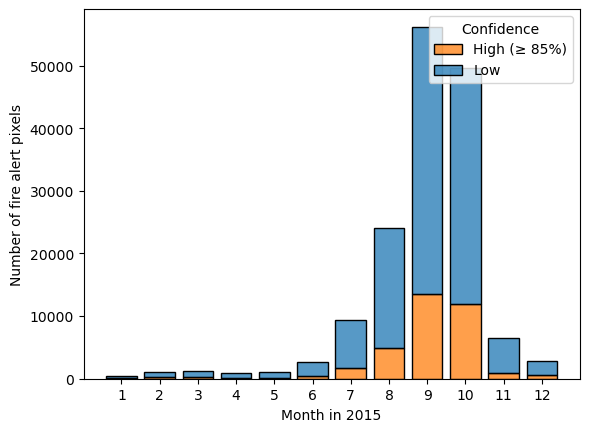

In [15]:
# check fires per month in 2015
modis_fa_2015 = modis_fa_vf[modis_fa_vf.YEAR == 2015]

sns.histplot(x="MONTH", 
             hue="HIGH_CONFIDENCE",
             multiple="stack", discrete=True,
             legend=False,
             shrink=.8,
             data=modis_fa_2015)

plt.xticks(np.arange(1,13,1))

plt.xlabel("Month in 2015")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

In [16]:
# reproject, then subset to before, during, and after fire detection period

start_date = '2015-08-01'
end_date = '2015-10-31'

modis_fa_reproj = modis_fa_vf.to_crs(projection)
# keep only high confidence points
modis__fa_reproj = modis_fa_reproj[modis_fa_reproj.CONFIDENCE >= confidence_threshold]

fires_before = modis__fa_reproj[modis__fa_reproj.ACQ_DATE < start_date]
fires_summer_2015 = modis__fa_reproj[modis__fa_reproj.ACQ_DATE.between(start_date,end_date)]
fires_after = modis__fa_reproj[modis__fa_reproj.ACQ_DATE > end_date]

continued in [here](#Fire-history)

# Burned area

created with GEE (see script)
from https://developers.google.com/earth-engine/datasets/catalog/ESA_CCI_FireCCI_5_1

In [17]:
import rioxarray as rxr
import rasterio 
import numpy as np
from rasterio.enums import Resampling # for reprojection

In [18]:
filepath_ba = "input-data/burned-area/burned-area-aug-to-oct-2015.tif"
burned_area = rxr.open_rasterio(filepath_ba)

In [19]:
# reproject
burned_area_reproj = burned_area.rio.reproject(projection, resampling=Resampling.bilinear)

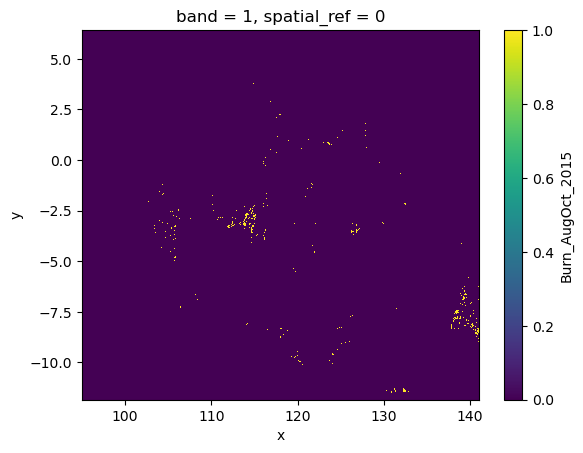

In [20]:
burned_area.plot()

# Peatlands

from Global Peatlands

In [21]:
import rioxarray as rxr
import xarray as xr
import rasterio 
import numpy as np

In [22]:
# load data as xarray
filepath_gp = "input-data/global-peatland-map/peatGPA22WGS_2cl.tif"
peatland = rxr.open_rasterio(filepath_gp)

# subset to Indonesia
peatland = peatland.sel(x=slice(indonesia.bounds.minx.item(),indonesia.bounds.maxx.item()), 
                        y=slice(indonesia.bounds.maxy.item(),indonesia.bounds.miny.item()))

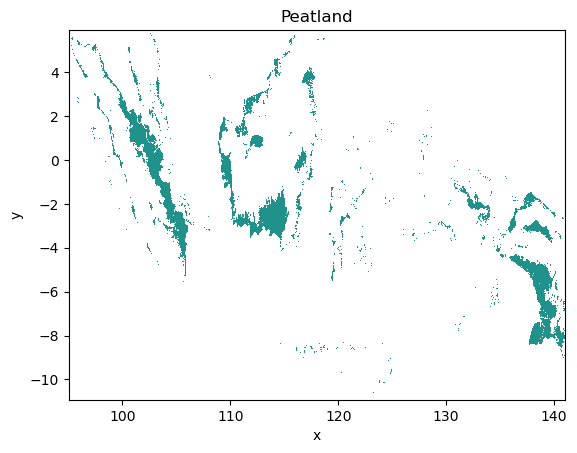

In [23]:
# set 255 (no peatland) and 2 (peat in soil matrix) to NaN
peatland_only = peatland.where(peatland == 1, other=np.nan)

peatland_only.plot(add_colorbar=False)
plt.title('Peatland')
plt.show()

In [24]:
# reproject to match burned area projection/resolution/grid
peatland_only_reproj = peatland_only.rio.reproject_match(burned_area_reproj, resampling=Resampling.bilinear)

In [25]:
# check where burned area and peatlands overlap

# merge both arrays
merged = xr.merge([burned_area_reproj.rename('burned_area'),
                   peatland_only_reproj.rename('peatland')],
                  compat='no_conflicts')

# add new column with category
categories = ['burned peatland', 'unburned peatland', 'burned other', 'other']
merged['category'] = xr.where((merged.burned_area == 1) & (merged.peatland == 1), 
                              1, 
                              xr.where((merged.burned_area == 0) & (merged.peatland == 1),
                                       2,
                                       xr.where((merged.burned_area == 1) & (merged.peatland != 1),
                                                3,
                                                4
                                               )))

In [26]:
# Area calculations

# reproject to equal area CRS - EPSG:8857 (Equal Earth) 
da = merged.category.astype(np.uint8)  # uint8 is perfect for small integer categories
da = da.rio.write_nodata(0)  # 0 is safe since your values are 1-4

categories_ea = da.rio.reproject('EPSG:8857', 
                                 resampling=Resampling.nearest,
                                 resolution=250) # set to 250x250m pixel size

categories_ea

<xarray.DataArray 'category' (band: 1, y: 9358, x: 17983)> Size: 168MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0],
        [4, 4, 4, ..., 0, 0, 0]]], shape=(1, 9358, 17983), dtype=uint8)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 75kB 8.234e+05 8.232e+05 ... -1.516e+06 -1.516e+06
  * x            (x) float64 144kB 9.01e+06 9.011e+06 ... 1.351e+07 1.351e+07
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  0

In [27]:
# Get pixel dimensions in meters (Web Mercator units are meters)
res_x = float(abs(categories_ea.x[1] - categories_ea.x[0]))  # width of one pixel in meters
res_y = float(abs(categories_ea.y[1] - categories_ea.y[0]))  # height of one pixel in meters
pixel_area_m2 = res_x * res_y
pixel_area_km2 = pixel_area_m2 / 1e6

np.sqrt(pixel_area_m2)

np.float64(250.0)

In [28]:
# Count pixels per category
categories, counts = np.unique(
    categories_ea.values[~np.isnan(categories_ea.values)].astype(int),
    return_counts=True
)

area_df = pd.DataFrame({
    "category": categories,
    "pixel_count": counts,
    "area_km2": counts * pixel_area_km2,
    "area_ha": counts * pixel_area_km2 * 100
})

In [29]:
area_df

,category,pixel_count,area_km2,area_ha
0,0,3864083,2.415052e+05,2.415052e+07
1,1,221774,1.386088e+04,1.386088e+06
2,2,5759649,3.599781e+05,3.599781e+07
3,3,191575,1.197344e+04,1.197344e+06
4,4,158247833,9.890490e+06,9.890490e+08


In [30]:
print("Total burned area in Aug-Oct 2015 (ha)")
(1.386088e6 + 1.197344e6) / 1e6

Total burned area in Aug-Oct 2015 (ha)


2.583432

In [31]:
print("Total peatland area (ha)")
(1.386088e6 + 3.599781e7) / 1e6

Total peatland area (ha)


37.383898

In [32]:
print("Total burned peatland area (ha)")
1.386088e6 / 1e6

Total burned peatland area (ha)


1.386088

# EVI

used Google Earth Engine (script in repository) to compute yearly raster files containing the mean annual EVI,
obtained from MODIS 

In [33]:
da = rxr.open_rasterio("input-data/modis-evi-test/EVI_2016_test.tif")
print(da.min().values, da.max().values)

-9999.0 0.7616565227508545


In [34]:
da = xr.where(da >= 0, da, np.nan)

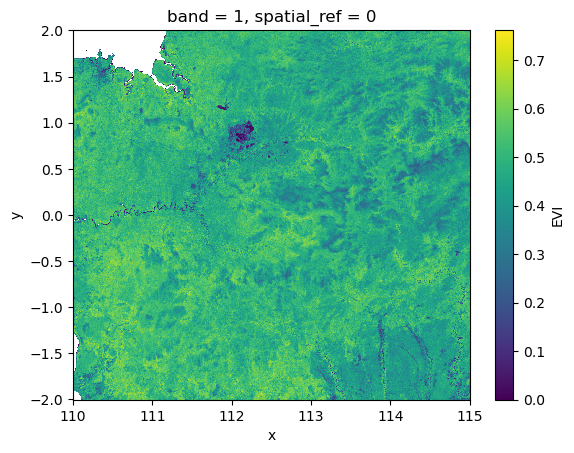

In [35]:
da.plot()

# Fire history

In [36]:
import geopandas as gpd
import xarray as xr
import rioxarray
import numpy as np

# Extract coordinates from your dataset
lons = merged.x.values
lats = merged.y.values

# Compute pixel size (assumes regular grid)
dlon = abs(lons[1] - lons[0])
dlat = abs(lats[1] - lats[0])

# Get point coordinates
px = fires_before.geometry.x.values
py = fires_before.geometry.y.values

# Map each point to a pixel index
col_idx = np.floor((px - (lons[0] - dlon / 2)) / dlon).astype(int)
row_idx = np.floor(((lats[0] + dlat / 2) - py) / dlat).astype(int)

# Filter out points that fall outside the grid
valid = (
    (col_idx >= 0) & (col_idx < len(lons)) &
    (row_idx >= 0) & (row_idx < len(lats))
)
col_idx, row_idx = col_idx[valid], row_idx[valid]

# Count points per pixel
count_array = np.zeros((len(lats), len(lons)), dtype=int)
np.add.at(count_array, (row_idx, col_idx), 1)

# Add as a new variable to the dataset
merged["fire_alerts_before"] = xr.DataArray(
    count_array,
    dims=["y", "x"],
    coords={"y": merged.y, "x": merged.x},
)


In [37]:
# do the same for 

# Get point coordinates
px = fires_after.geometry.x.values
py = fires_after.geometry.y.values

# Map each point to a pixel index
col_idx = np.floor((px - (lons[0] - dlon / 2)) / dlon).astype(int)
row_idx = np.floor(((lats[0] + dlat / 2) - py) / dlat).astype(int)

# Filter out points that fall outside the grid
valid = (
    (col_idx >= 0) & (col_idx < len(lons)) &
    (row_idx >= 0) & (row_idx < len(lats))
)
col_idx, row_idx = col_idx[valid], row_idx[valid]

# Count points per pixel
count_array = np.zeros((len(lats), len(lons)), dtype=int)
np.add.at(count_array, (row_idx, col_idx), 1)

# Add as a new variable to the dataset
merged["fire_alerts_after"] = xr.DataArray(
    count_array,
    dims=["y", "x"],
    coords={"y": merged.y, "x": merged.x},
)

In [38]:
# Check burned area 2015 that burned again vs. did not
merged['burned_again'] = xr.where((merged.burned_area == 1) & (merged.fire_alerts_after >= 1),
                                  1,
                                  xr.where((merged.burned_area == 1) & (merged.fire_alerts_after == 0),
                                           0,
                                           np.nan)
                                 )

In [39]:
merged['study_area'] = xr.where(merged.burned_again == 0, 1, np.nan)

merged['study_area'] = merged['study_area'].rio.write_crs(merged.rio.crs)

In [40]:
study_area = merged['study_area'].rio.reproject('EPSG:4326', resampling=Resampling.bilinear)

In [41]:
study_area

<xarray.DataArray 'study_area' (band: 1, y: 8129, x: 20468)> Size: 1GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(1, 8129, 20468))
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 65kB 6.415 6.413 6.411 ... -11.83 -11.84 -11.84
  * x            (x) float64 164kB 95.01 95.02 95.02 95.02 ... 141.0 141.0 141.0
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

In [42]:
study_area.to_netcdf('study_area.nc')

# Land cover

from Global Landcover map 2015 by Li et al. (2023)

In [43]:
# 95.012706	-10.922621	140.977627	5.910102 -->  E 95-140    N 0-6   S 0-(-11)

In [44]:
'92E' '96E' '100E' '104E' '108E' '112E' '116E' 

'92E96E100E104E108E112E116E'

In [45]:
e_nrs = np.arange(92,145,4)
s_nrs = [2,6]
n_nrs = [2]



In [49]:
# load TIFF files (map split into multiple tiles)

import rioxarray
from rioxarray.merge import merge_arrays

# set up file names
file_names = []
for e_coord in np.arange(92,145,4):
    file_name = f'GLC-2015_{e_coord}E_2N'
    file_names.append(file_name)
    file_name = f'GLC-2015_{e_coord}E_2S'
    file_names.append(file_name)
    file_name = f'GLC-2015_{e_coord}E_6S'
    file_names.append(file_name)

# open each file
arrays = [rioxarray.open_rasterio(f'input-data/land-cover/{f}.tif') for f in file_names]

# merge into one
merged = merge_arrays(arrays)

RasterioIOError: input-data/land-cover/GLC-2015_92E_2S.tif: No such file or directory

In [48]:
conda install osgeo

Jupyter detected...
2 channel Terms of Service accepted
doneieving notices: - 
Channels:
 - defaults
Platform: osx-arm64
doneecting package metadata (repodata.json): / 
failedg environment: \ 

PackagesNotFoundError: The following packages are not available from current channels:

  - osgeo

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.



Note: you may need to restart the kernel to use updated packages.


In [46]:
import os
import numpy as np
import rioxarray as rxr
import xarray as xr
from osgeo import gdal

file_names = []
for e_coord in np.arange(92, 145, 4):
    for suffix in ['2N', '2S', '6S']:
        file_name = f'GLC-2015_{e_coord}E_{suffix}'
        path = f'input-data/land-cover/{file_name}.tif'
        if os.path.exists(path):
            file_names.append(path)

# --- Option A: VRT (fastest, recommended) ---
# Build a virtual mosaic on disk — no data is actually read or copied
vrt_path = "merged.vrt"
gdal.BuildVRT(vrt_path, file_names)

# Open the VRT lazily with dask chunks
da = rxr.open_rasterio(vrt_path, chunks={"x": 2048, "y": 2048}, lock=False)

# Now apply your mask lazily — computation only happens when you call .compute()
forest_code = 20
binary = xr.where(da == forest_code, 1, 0).astype("uint8")
binary = binary.rio.write_crs("EPSG:4326")

ModuleNotFoundError: No module named 'osgeo'

In [8]:
example = rxr.open_rasterio('input-data/land-cover/GLC-2015_100E_2N.tif')
example.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [ ]:
import os
import numpy as np
import rioxarray as rxr
import xarray as xr
import dask
from rioxarray.merge import merge_arrays


file_names = []
for e_coord in np.arange(92, 145, 4):
    for suffix in ['2N', '2S', '6S']:
        file_name = f'GLC-2015_{e_coord}E_{suffix}'
        path = f'input-data/land-cover/{file_name}.tif'
        if os.path.exists(path):
            file_names.append(path)

# load arrays lazily with chunks (don't fully load)
arrays = [rxr.open_rasterio(f) for f in file_names] # open lazily with chunks

# create binary mask (1 == forest area)
forest_code = 20
binary_arrays = [
    xr.where(arr == forest_code, 1, 0).astype("uint8")
    for arr in arrays
]

# ascribe CRS
binary_arrays = [
    arr.rio.write_crs('EPSG:4326')
    for arr in binary_arrays
]

# merge masks
merged = merge_arrays(binary_arrays)

In [ ]:
xr.open_mfdataset(file_names, chunks='auto')

In [23]:
exmpl = binary_arrays[1].rio.write_crs('EPSG:4326')
exmpl.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

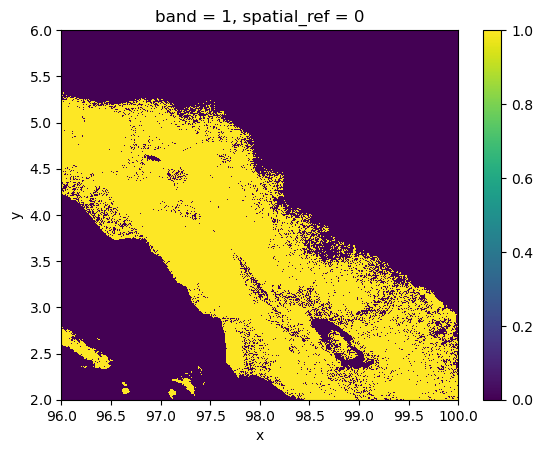

In [24]:
exmpl.plot()

In [11]:
import os
import numpy as np
import rioxarray as rxr
import xarray as xr
import dask

file_names = []
for e_coord in np.arange(92, 145, 4):
    for suffix in ['2N', '2S', '6S']:
        file_name = f'GLC-2015_{e_coord}E_{suffix}'
        path = f'input-data/land-cover/{file_name}.tif'
        if os.path.exists(path):
            file_names.append(path)

binary_arrays = []

forest_code = 20

for f in file_names:
    arr = rioxarray.open_rasterio(
        f,
        chunks={"x": 2048, "y": 2048},
        masked=False
    ).squeeze("band", drop=True)

    mask = xr.where(arr == forest_code, 1, 0).astype("uint8")

    # Reattach spatial metadata
    mask = mask.rio.write_crs(arr.rio.crs)
    mask = mask.rio.write_transform(arr.rio.transform())

    binary_arrays.append(mask)

merged = merge_arrays(binary_arrays)

KeyboardInterrupt: 

# Study area

In [ ]:
# burned dry season 2015
# did not burn after 2015
# peatland
# forest 2015
# forest 2021


# Export

In [42]:
# make sure all layers have the same projection
for var in merged_ds.data_vars:
    merged[var] = merged[var].rio.write_crs(merged.rio.crs)

merged.to_netcdf('output.nc')